# Deep Learning Practical Report 2(ANN Adult census income)

## Task 1: Data Loading, Cleaning & Exploratory Data Analysis

### 1.1 Load and inspect the dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("adult.csv")
print(df.shape)
print(df.dtypes)
display(df.head())


(48842, 15)
age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
for col in df.select_dtypes('object'):
    df[col] = df[col].str.strip()

### 1.2 Handle missing values

In [4]:
# missing values have ? so I replace with NAN

df.replace('?',np.nan,inplace=True)
print(df.isnull().sum())

df.dropna(inplace=True)
print(df.shape)

# I dropped the missing rows because all the columns with missing values were categorical values with many categories and imputing them with 
# mode will disrupt the balanced and true nature of dataset and also the missing values were a small fraction of dataset so removing it was much safer. 

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64
(45222, 15)


### 1.3 Drop redundant columns

In [5]:
# fnlwgt will be dropped because its not a real feature and doesnt have a significance of a adult. 
# education will be dropped because education-num shows the same thing numerically.

df.drop(columns=['fnlwgt','education'],inplace=True)
print(df.shape)

(45222, 13)


### 1.4 Encode the target

income
0    34014
1    11208
Name: count, dtype: int64


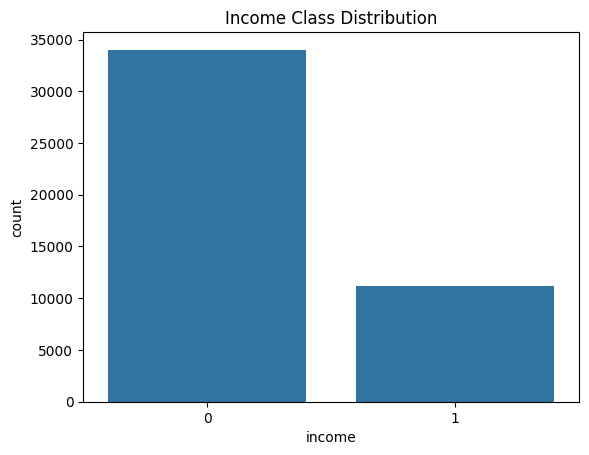

In [6]:
#  0 (<=50K) and 1 (>50K)
df['income'] = (df['income'] == '>50K').astype(int)
print(df['income'].value_counts())

sns.countplot(x='income', data=df)
plt.title('Income Class Distribution')
plt.savefig("Income Class Distribution",dpi=300)
plt.show()

# We will track F1-score, Precision, and Recall alongside accuracy throughout.


### 1.5 Exploratory visualisations

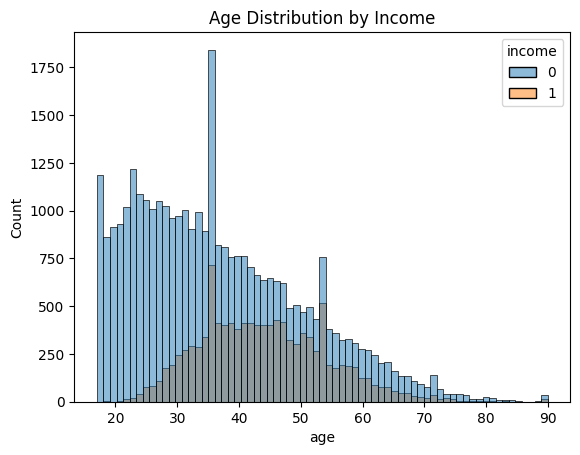

In [7]:
sns.histplot(data=df, x='age', hue='income')
plt.title('Age Distribution by Income')
plt.savefig('Age Distribution by Income',dpi=300)
plt.show()

# Older individuals (roughly 35-55) are more likely to earn >50K, while the <=50K group skews younger.

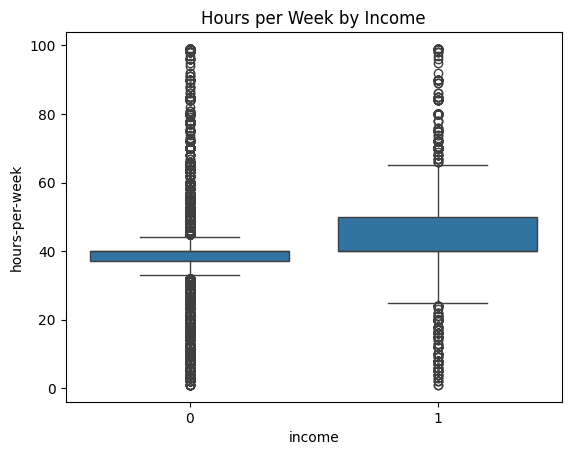

In [8]:
sns.boxplot(data=df, x='income', y='hours-per-week')
plt.title('Hours per Week by Income')
plt.savefig('Hours per Week by Income',dpi=300)
plt.show()

# People earning >50K tend to work more hours per week, with a higher median and less spread than the <=50K group.

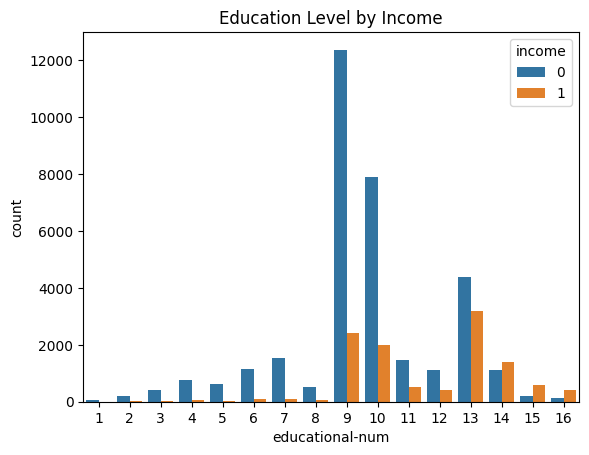

In [9]:
sns.countplot(data=df, x='educational-num', hue='income')
plt.title('Education Level by Income')
plt.savefig('Education Level by Income',dpi=300)
plt.show()

# Higher education levels are associated with a much higher share of >50K earners, showing education is a strong individual predictor of income.

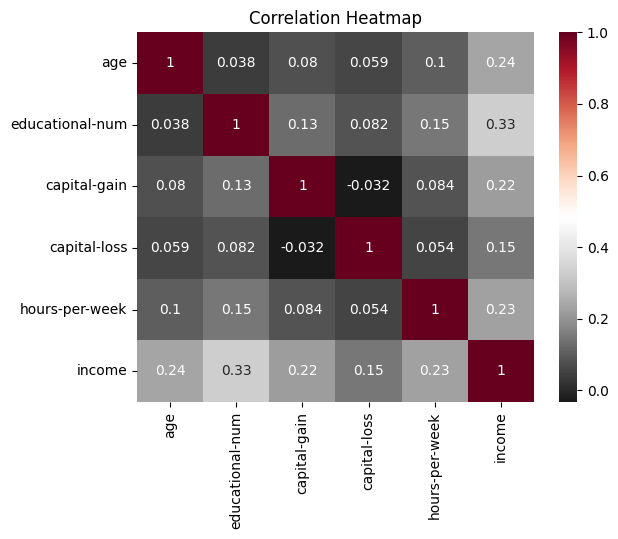

In [10]:
num_cols = ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'income']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='RdGy_r')
plt.title('Correlation Heatmap')
plt.savefig('Correlation Heatmap',dpi=300)
plt.show()

# educational-num and hours-per-week show the strongest positive correlation with income among
# numeric features, followed by age. No two numeric features are strongly collinear with each other.

### 1.6 Encode categoricals & scale numerics

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('income', axis=1)
y = df['income']
X = pd.get_dummies(X, drop_first=True) # converts categorical col into new numerical cols and drops first new num col as one col is enough for understanding. 
print(X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_features = ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(45222, 80)
(36177, 80) (9045, 80)
income
0    0.752163
1    0.247837
Name: proportion, dtype: float64
income
0    0.752128
1    0.247872
Name: proportion, dtype: float64


## Task 2: MLP Architecture — Baseline ANN

### 2.1 Define the reusable build_ann() function

In [12]:
import tensorflow as tf
from tensorflow import keras

def build_ann(input_dim, hidden_units=[128, 64], activation='relu',
              initializer='glorot_uniform', use_batch_norm=False,
              optimizer='adam', loss='binary_crossentropy'):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(input_dim,)))
    for units in hidden_units:
        model.add(keras.layers.Dense(units, kernel_initializer=initializer))
        if use_batch_norm:
            model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Activation(activation))
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
    return model

### 2.2 Baseline ANN architecture

In [13]:
model_base = build_ann(input_dim=X_train.shape[1])
model_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,689 (73.00 KB)

 Trainable params: 18,689 (73.00 KB)

 Non-trainable params: 0 (0.00 B)

### 2.3 Train the baseline

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8441 - loss: 0.3329 - val_accuracy: 0.8516 - val_loss: 0.3222
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 952us/step - accuracy: 0.8530 - loss: 0.3138 - val_accuracy: 0.8530 - val_loss: 0.3234
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 948us/step - accuracy: 0.8541 - loss: 0.3105 - val_accuracy: 0.8532 - val_loss: 0.3196
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 950us/step - accuracy: 0.8570 - loss: 0.3074 - val_accuracy: 0.8507 - val_loss: 0.3227
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step - accuracy: 0.8579 - loss: 0.3047 - val_accuracy: 0.8546 - val_loss: 0.3207
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8591 - loss: 0.3013 - val_accuracy: 0.8546 - val_loss: 0.3216
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 962us/step - accuracy: 0.8616 - loss: 0.2989 - val_accuracy: 0.8543 - val_loss: 0.3206
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 934us/step - accuracy: 0.8611 - loss: 0.2968 - val_

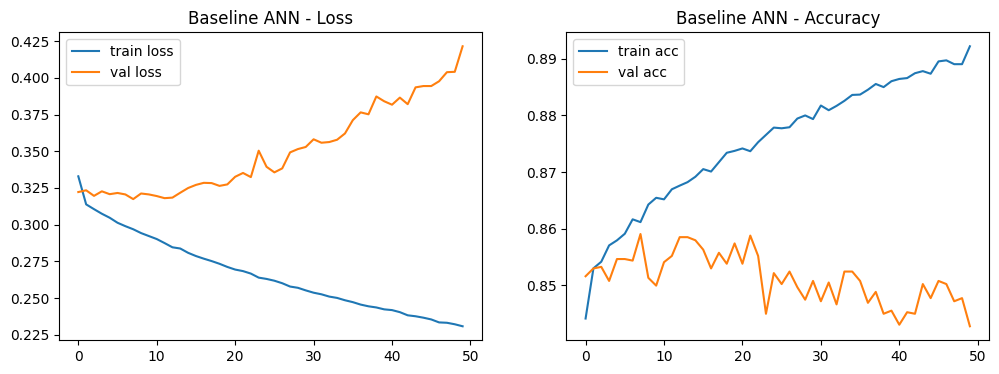

In [14]:
# Training for 50 epochs, holding out 10% of the training data for validation, then plotting the loss and accuracy curves.

history_base = model_base.fit(X_train, y_train, epochs=50, batch_size=64,
                               validation_split=0.1, verbose=1)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_base.history['loss'], label='train loss')
plt.plot(history_base.history['val_loss'], label='val loss')
plt.title('Baseline ANN - Loss')
plt.legend()
plt.savefig('Baseline ANN - Loss',dpi=300)

plt.subplot(1,2,2)
plt.plot(history_base.history['accuracy'], label='train acc')
plt.plot(history_base.history['val_accuracy'], label='val acc')
plt.title('Baseline ANN - Accuracy')
plt.legend()
plt.savefig('Baseline ANN - Accuracy',dpi=300)

plt.show()

### 2.4 Evaluate the baseline with full metrics

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      6803
           1       0.74      0.56      0.64      2242

    accuracy                           0.84      9045
   macro avg       0.80      0.75      0.77      9045
weighted avg       0.83      0.84      0.83      9045



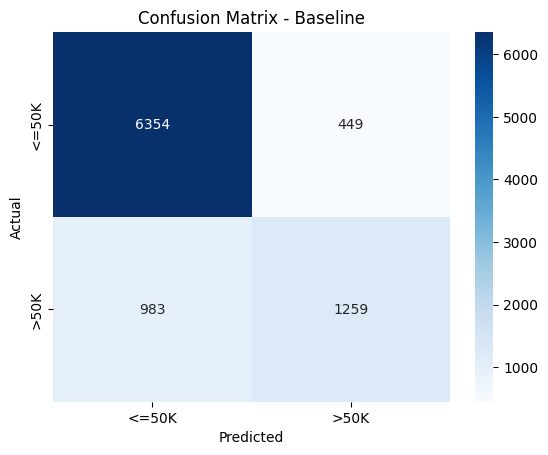

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_prob = model_base.predict(X_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K','>50K'], yticklabels=['<=50K','>50K'])
plt.title('Confusion Matrix - Baseline')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('Confusion Matrix - Baseline',dpi=300)
plt.show()

### 2.5 Why tabular data suits ANN
Tabular data like this (numeric + one-hot encoded categorical features) is the natural input for a
fully connected MLP, unlike image data (which needs CNNs) or sequence data (which needs RNNs).
Each input neuron receives one scaled feature, and the hidden layers learn combinations between
features — like age combined with education level — that a simple logistic regression can't
capture on its own.

## Task 3: Activation Functions — Comparison Experiment

### 3.1 Train 4 models with different hidden activations

In [16]:
histories = {}
models = {}

for act in ['relu', 'tanh', 'sigmoid', 'elu']:
    m = build_ann(input_dim=X_train.shape[1], activation=act)
    h = m.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=0)
    histories[act] = h
    models[act] = m
    print(act, 'done - final val_accuracy:', round(h.history['val_accuracy'][-1], 4))

relu done - final val_accuracy: 0.8452
tanh done - final val_accuracy: 0.8554
sigmoid done - final val_accuracy: 0.8546
elu done - final val_accuracy: 0.8535


### 3.2 Activation comparison — 4-panel plot

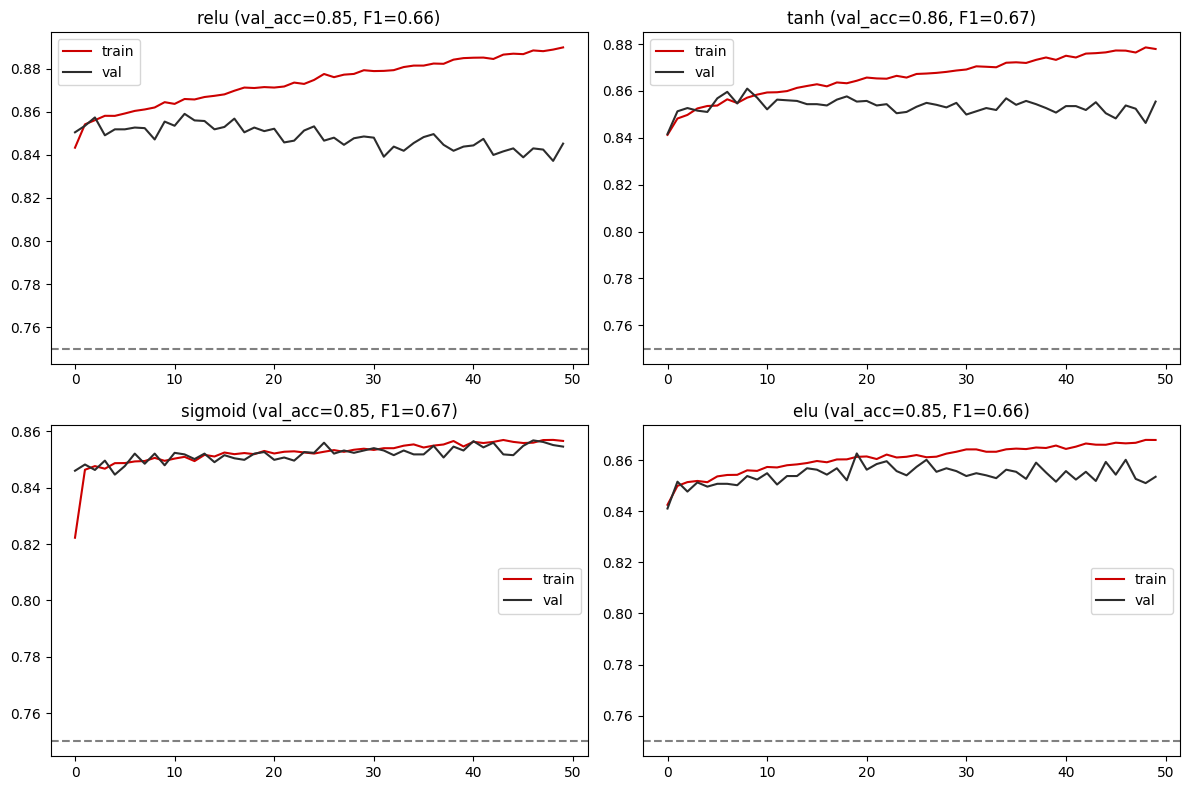

In [17]:
from sklearn.metrics import f1_score

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, act in enumerate(['relu', 'tanh', 'sigmoid', 'elu']):
    h = histories[act]
    axes[i].plot(h.history['accuracy'], color='#CC0000', label='train')
    axes[i].plot(h.history['val_accuracy'], color='#2C2C2C', label='val')
    axes[i].axhline(0.75, linestyle='--', color='gray')

    y_prob = models[act].predict(X_test, verbose=0).flatten()
    y_pred = (y_prob > 0.5).astype(int)
    f1 = f1_score(y_test, y_pred)
    val_acc = h.history['val_accuracy'][-1]

    axes[i].set_title(f'{act} (val_acc={val_acc:.2f}, F1={f1:.2f})')
    axes[i].legend()

plt.tight_layout()
plt.savefig("accuracy vs val accuracy of 4 models with same parameters diff. act func.", dpi=300)
plt.show()

### 3.3 Dead neuron check — ReLU

Dead neuron fraction: 0.631703125


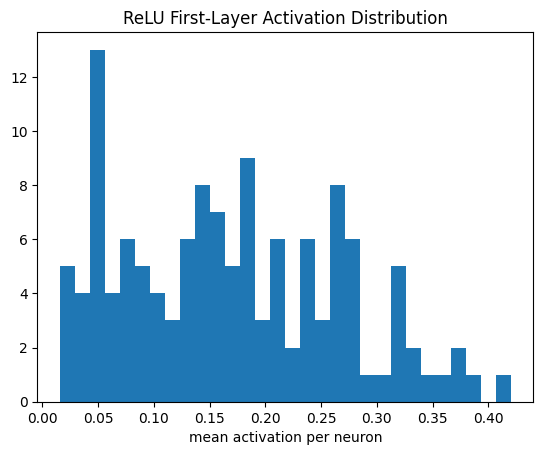

In [19]:
W1, b1 = models['relu'].layers[0].get_weights()
z1 = X_test[:500].values @ W1 + b1
a1 = np.maximum(z1, 0)   # relu applied manually

dead_fraction = np.mean(a1 == 0)
print('Dead neuron fraction:', dead_fraction)

plt.hist(a1.mean(axis=0), bins=30)
plt.title('ReLU First-Layer Activation Distribution')
plt.xlabel('mean activation per neuron')
plt.savefig('ReLU First-Layer Activation Distribution', dpi=300)
plt.show()

A noticeable fraction of ReLU neurons output 0 for every sample in this batch — these are "dead"
neurons that stopped contributing because their input is always negative, so their gradient is
always 0 too. ELU avoids this because it allows small negative outputs (alpha*(e^x - 1) for
negative x) instead of a hard 0, keeping the gradient path alive even for negative inputs.

### 3.4 Gradient flow check — Sigmoid hidden layers

In [20]:
model_sig = models['sigmoid']

# take a small batch of test data
x_batch = X_test[:64].values
y_batch = y_test[:64].values.reshape(-1, 1)

x_batch = tf.constant(x_batch, dtype=tf.float32)
y_batch = tf.constant(y_batch, dtype=tf.float32)

# tf.GradientTape just watches the process and tells the observation later
with tf.GradientTape() as tape:
    predictions = model_sig(x_batch)
    loss = keras.losses.binary_crossentropy(y_batch, predictions)
    loss = tf.reduce_mean(loss)

# get the gradient for every layer's weights
grads = tape.gradient(loss, model_sig.trainable_variables)

# print average gradient size for each layer
for var, grad in zip(model_sig.trainable_variables, grads):
    print(var.name, '->', np.mean(np.abs(grad)))

kernel -> 0.00037891703
bias -> 0.0041007227
kernel -> 0.0010476392
bias -> 0.003350386
kernel -> 0.041659527
bias -> 0.12762


If the gradients in the first layer are much smaller than in the output layer, that's vanishing
gradients

### 3.5 Activation summary

| Activation | Output Range | Zero-Centred | Vanishing Gradient Risk | Dead Neuron Risk |
|---|---|---|---|---|
| ReLU | [0, inf) | No | Low | High |
| Tanh | (-1, 1) | Yes | Medium | Low |
| Sigmoid | (0, 1) | No | High | Low |
| ELU | (-alpha, inf) | Mostly | Low | Very Low |
| Sigmoid (output layer only) | (0, 1) | No | N/A | N/A |

The output layer always uses sigmoid regardless of which activation is used in the hidden layers,
because we need a single probability between 0 and 1 for binary classification.

Based on the val_accuracy and F1 scores printed above, note here which activation performed best
on this dataset and give a one-line reason (e.g. ReLU/ELU usually win on tabular data like this
because they train faster and avoid vanishing gradients, while sigmoid hidden layers tend to
train slower for deeper/wider nets).

## Task 4: Weight Initialization Techniques

### 4.1 Why initialisation matters
If every weight starts at 0, every neuron in a layer computes the exact same output and gets the
exact same gradient during training. This is the symmetry problem — the whole layer behaves like
a single neuron no matter how wide it is, and it never breaks out of that because all neurons
keep updating identically.

Glorot (Xavier) initialisation picks starting weights with variance = 2 / (fan_in + fan_out) — a
good balance for tanh/sigmoid layers. He initialisation uses variance = 2 / fan_in — the extra
factor of 2 makes up for ReLU zeroing out roughly half of all activations, keeping the signal
strength stable through a ReLU network.

### 4.2 Train 5 models with different initialisers
Training the same architecture 5 times, changing only the initializer each time: glorot_uniform,
glorot_normal, he_uniform, he_normal, and zeros (to show the failure case).

In [21]:
init_histories = {}
init_models = {}

inits = ['glorot_uniform', 'glorot_normal', 'he_uniform', 'he_normal', 'zeros']

for init in inits:
    m = build_ann(input_dim=X_train.shape[1], activation='relu', initializer=init)
    h = m.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=0)
    init_histories[init] = h
    init_models[init] = m
    print(init, '- final val_accuracy:', round(h.history['val_accuracy'][-1], 4))

glorot_uniform - final val_accuracy: 0.8394
glorot_normal - final val_accuracy: 0.8389
he_uniform - final val_accuracy: 0.8452
he_normal - final val_accuracy: 0.8411
zeros - final val_accuracy: 0.7526


### 4.3 Convergence speed comparison

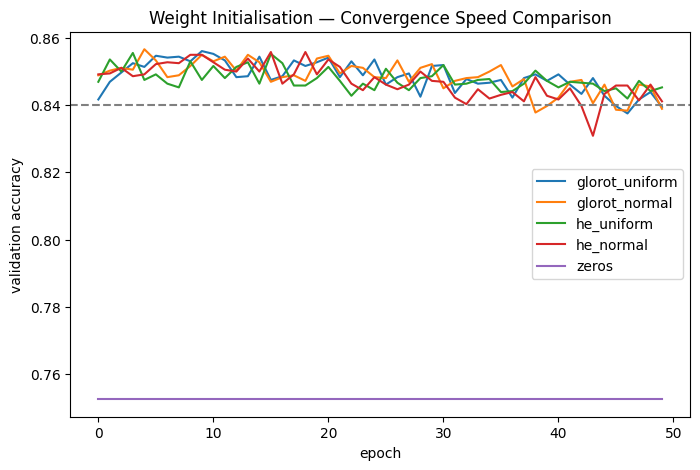

In [23]:
plt.figure(figsize=(8, 5))

for init in inits:
    plt.plot(init_histories[init].history['val_accuracy'], label=init)

plt.axhline(0.84, linestyle='--', color='gray')
plt.title('Weight Initialisation — Convergence Speed Comparison')
plt.xlabel('epoch')
plt.ylabel('validation accuracy')
plt.legend()
plt.savefig('Weight Initialisation — Convergence Speed Comparison', dpi=300)
plt.show()

### 4.4 Zeros failure demonstration

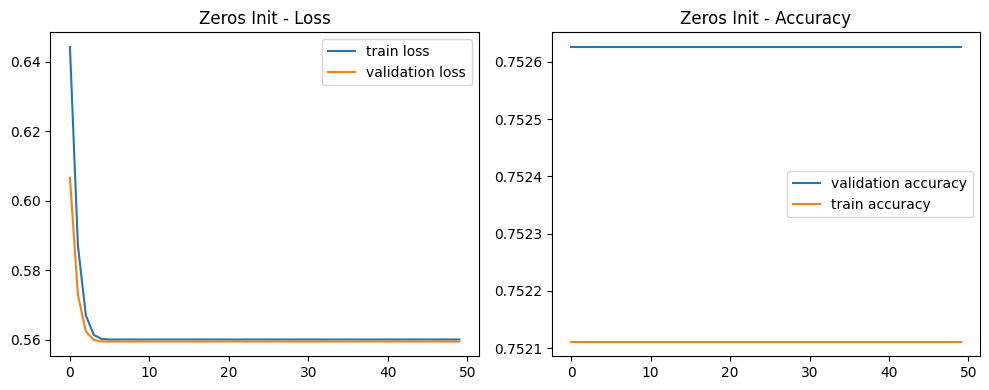

In [27]:
h_zeros = init_histories['zeros']

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(h_zeros.history['loss'], label="train loss")
plt.plot(h_zeros.history['val_loss'], label="validation loss")
plt.title('Zeros Init - Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(h_zeros.history['val_accuracy'], label="validation accuracy")
plt.plot(h_zeros.history['accuracy'], label="train accuracy")
plt.title('Zeros Init - Accuracy')
plt.legend()


plt.tight_layout()
plt.savefig('zero failure demonstration', dpi=300)
plt.show()

The zeros-initialised model gets stuck near 75% accuracy and stays flat — this is exactly the
majority-class baseline. It never learns anything real because every neuron started identical and
kept updating identically, so the network effectively acts like a single neuron outputting a
constant prediction. This shows initialisation is not a minor detail — it can completely break
training.

### 4.5 Weight distribution — before vs after training

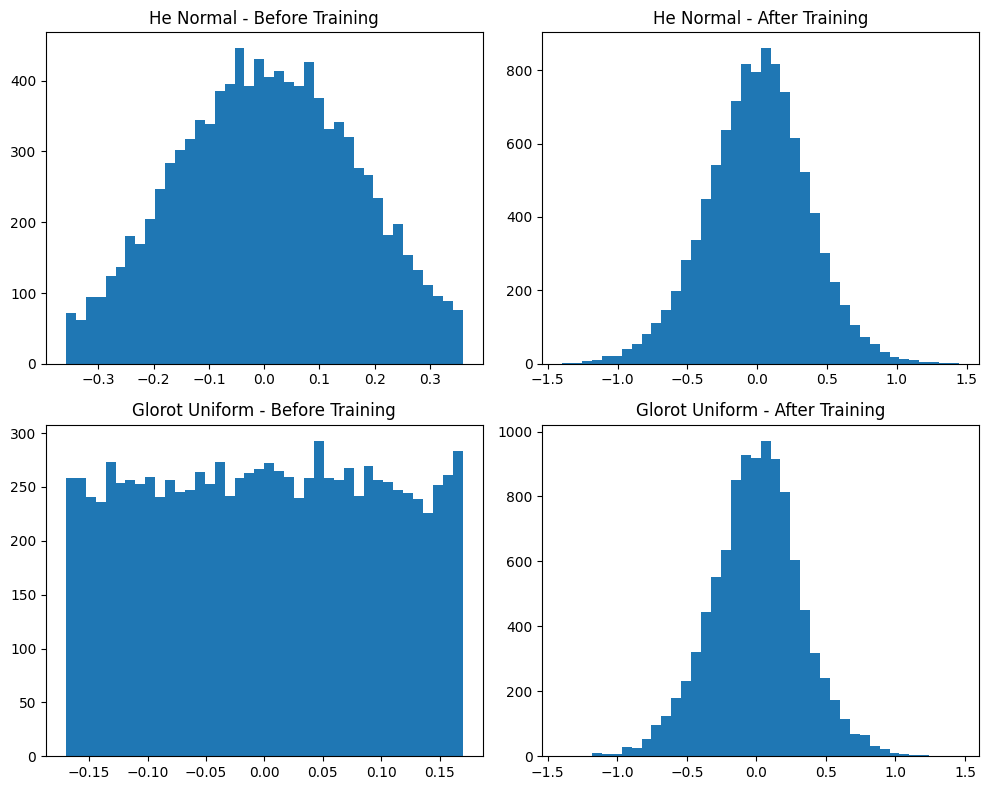

In [28]:
# he_normal model
he_model = build_ann(input_dim=X_train.shape[1], activation='relu', initializer='he_normal')
he_weights_before = he_model.layers[0].get_weights()[0].copy()
he_model.fit(X_train, y_train, epochs=50, batch_size=64, verbose=0)
he_weights_after = he_model.layers[0].get_weights()[0].copy()

# glorot_uniform model
glorot_model = build_ann(input_dim=X_train.shape[1], activation='relu', initializer='glorot_uniform')
glorot_weights_before = glorot_model.layers[0].get_weights()[0].copy()
glorot_model.fit(X_train, y_train, epochs=50, batch_size=64, verbose=0)
glorot_weights_after = glorot_model.layers[0].get_weights()[0].copy()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0,0].hist(he_weights_before.flatten(), bins=40)
axes[0,0].set_title('He Normal - Before Training')

axes[0,1].hist(he_weights_after.flatten(), bins=40)
axes[0,1].set_title('He Normal - After Training')

axes[1,0].hist(glorot_weights_before.flatten(), bins=40)
axes[1,0].set_title('Glorot Uniform - Before Training')

axes[1,1].hist(glorot_weights_after.flatten(), bins=40)
axes[1,1].set_title('Glorot Uniform - After Training')

plt.tight_layout()
plt.savefig("weight distribution before vs after training", dpi=300)
plt.show()

Before training, each initialiser produces its own characteristic shape — He Normal starts wider
(larger variance) than Glorot Uniform, matching their formulas. After 50 epochs, both
distributions have shifted and spread out from their starting shape — this shows that
backpropagation reshapes the weights during learning; the initialiser only decides the starting
point, not the final result.

## Task 5: Loss Functions

### 5.1 Binary Cross-Entropy — the correct loss

### 5.2 MSE as classification loss — wrong tool experiment

In [29]:
model_mse = build_ann(input_dim=X_train.shape[1], loss='mean_squared_error', initializer='he_normal')
h_mse = model_mse.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=0)

from sklearn.metrics import f1_score

y_pred_base = (model_base.predict(X_test, verbose=0).flatten() > 0.5).astype(int)
y_pred_mse = (model_mse.predict(X_test, verbose=0).flatten() > 0.5).astype(int)

print('Baseline (BCE) F1:', f1_score(y_test, y_pred_base))
print('MSE F1:', f1_score(y_test, y_pred_mse))

Baseline (BCE) F1: 0.6374683544303797
MSE F1: 0.6595547309833024


### 5.3 Weighted Binary Cross-Entropy — handling class imbalance

In [30]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}
print(class_weight_dict)

model_wbce = build_ann(input_dim=X_train.shape[1], initializer='he_normal')
h_wbce = model_wbce.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1,
                         class_weight=class_weight_dict, verbose=0)

y_pred_wbce = (model_wbce.predict(X_test, verbose=0).flatten() > 0.5).astype(int)

from sklearn.metrics import precision_score, recall_score

print('Baseline  - Precision:', precision_score(y_test, y_pred_base),
      'Recall:', recall_score(y_test, y_pred_base), 'F1:', f1_score(y_test, y_pred_base))
print('Weighted BCE - Precision:', precision_score(y_test, y_pred_wbce),
      'Recall:', recall_score(y_test, y_pred_wbce), 'F1:', f1_score(y_test, y_pred_wbce))

{0: np.float64(0.6647495498144133), 1: np.float64(2.0174548293553425)}
Baseline  - Precision: 0.7371194379391101 Recall: 0.5615521855486173 F1: 0.6374683544303797
Weighted BCE - Precision: 0.5548071034905082 Recall: 0.808206958073149 F1: 0.6579520697167756


Weighted BCE makes mistakes on class 1 (>50K) count for more during training. This raises Recall
for class 1 — the model catches more true high-earners — usually at some cost to Precision. In an
income-targeting application, missing a genuine high earner is often more costly than a false
alarm, so this trade-off is usually worth it.

### 5.4 Focal Loss — advanced imbalance handling

In [31]:
def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        weight = alpha * y_true * (1 - y_pred)**gamma + (1 - alpha) * (1 - y_true) * y_pred**gamma
        return tf.reduce_mean(weight * bce)
    return loss_fn

model_focal = build_ann(input_dim=X_train.shape[1], initializer='he_normal', loss=focal_loss())
h_focal = model_focal.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=0)

y_pred_focal = (model_focal.predict(X_test, verbose=0).flatten() > 0.5).astype(int)

print('Weighted BCE - Recall:', recall_score(y_test, y_pred_wbce), 'F1:', f1_score(y_test, y_pred_wbce))
print('Focal Loss   - Recall:', recall_score(y_test, y_pred_focal), 'F1:', f1_score(y_test, y_pred_focal))

Weighted BCE - Recall: 0.808206958073149 F1: 0.6579520697167756
Focal Loss   - Recall: 0.43800178412132024 F1: 0.5621064682312535


### 5.5 Loss function summary

| Loss Function | Best For | Imbalance Handling |
|---|---|---|
| BCE | Standard binary classification | None |
| Weighted BCE | Imbalanced binary classification | Reweights loss by class frequency |
| MSE (classification) | Not recommended for classification | None, and gradient can vanish at saturation |
| Focal Loss | Extreme imbalance | Down-weights easy examples, focuses on hard ones |



## Task 6: Batch Normalization

### 6.1 Build ANN with Batch Normalization

In [32]:
model_bn = build_ann(input_dim=X_train.shape[1], initializer='he_normal', use_batch_norm=True)
model_bn.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 128)            │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,457 (76.00 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 384 (1.50 KB)

Each BatchNormalization layer adds 4 x neurons parameters: gamma, beta, moving_mean, and
moving_variance. Only gamma and beta are trainable — moving_mean and moving_variance are just
running statistics updated automatically during training, not learned through gradients.

### 6.2 Why Batch Normalization
As a network trains, the weights in each layer keep changing, which means the distribution of
values flowing into the next layer keeps shifting too. This forces every downstream layer to
constantly re-adapt to a moving target — called Internal Covariate Shift (Ioffe & Szegedy, 2015).

Batch Normalization fixes this by normalising each layer's input to zero mean and unit variance
within every mini-batch, then applying a learnable scale (gamma) and shift (beta):
BN(x) = gamma * (x - batch_mean) / sqrt(batch_variance + epsilon) + beta

At inference time (predicting on new data), BatchNorm uses running averages of mean and variance
collected during training, not the statistics of the current batch. Benefits for tabular data:
faster convergence, less sensitivity to learning rate choice, and a mild regularising effect.

### 6.3 Train and compare — with vs without BatchNorm

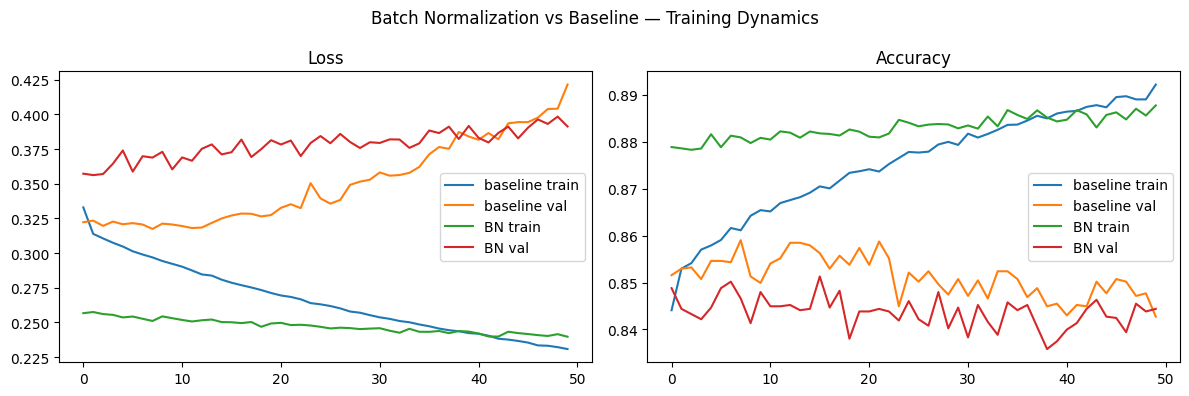

Baseline - Accuracy: 0.8468767274737424 F1: 0.6629350206862984
BatchNorm - Accuracy: 0.840685461580984 F1: 0.6451612903225806


In [34]:
h_bn = model_bn.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=0)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_base.history['loss'], label='baseline train')
plt.plot(history_base.history['val_loss'], label='baseline val')
plt.plot(h_bn.history['loss'], label='BN train')
plt.plot(h_bn.history['val_loss'], label='BN val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_base.history['accuracy'], label='baseline train')
plt.plot(history_base.history['val_accuracy'], label='baseline val')
plt.plot(h_bn.history['accuracy'], label='BN train')
plt.plot(h_bn.history['val_accuracy'], label='BN val')
plt.title('Accuracy')
plt.legend()

plt.suptitle('Batch Normalization vs Baseline — Training Dynamics')
plt.tight_layout()
plt.savefig("Batch Normalization vs Baseline — Training Dynamics",dpi=300)
plt.show()

from sklearn.metrics import accuracy_score, f1_score

y_pred_bn = (model_bn.predict(X_test, verbose=0).flatten() > 0.5).astype(int)
print('Baseline - Accuracy:', accuracy_score(y_test, y_pred), 'F1:', f1_score(y_test, y_pred))
print('BatchNorm - Accuracy:', accuracy_score(y_test, y_pred_bn), 'F1:', f1_score(y_test, y_pred_bn))

### 6.4 BatchNorm position experiment

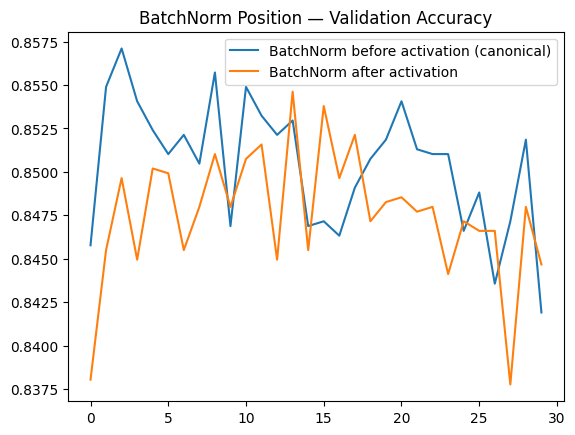

Before-activation final val_acc: 0.8419016003608704
After-activation final val_acc: 0.8446655869483948


In [36]:
# canonical: Dense -> BatchNorm -> Activation
model_bn_before = build_ann(input_dim=X_train.shape[1], initializer='he_normal', use_batch_norm=True)
h_before = model_bn_before.fit(X_train, y_train, epochs=30, batch_size=64, validation_split=0.1, verbose=0)

# alternative: Dense -> Activation -> BatchNorm
model_bn_after = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(128, kernel_initializer='he_normal'),
    keras.layers.Activation('relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(64, kernel_initializer='he_normal'),
    keras.layers.Activation('relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(1, activation='sigmoid')
])
model_bn_after.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
h_after = model_bn_after.fit(X_train, y_train, epochs=30, batch_size=64, validation_split=0.1, verbose=0)

plt.plot(h_before.history['val_accuracy'], label='BatchNorm before activation (canonical)')
plt.plot(h_after.history['val_accuracy'], label='BatchNorm after activation')
plt.title('BatchNorm Position — Validation Accuracy')
plt.legend()
plt.savefig("BatchNorm Position — Validation Accuracy",dpi=300)
plt.show()

print('Before-activation final val_acc:', h_before.history['val_accuracy'][-1])
print('After-activation final val_acc:', h_after.history['val_accuracy'][-1])

### 6.5 Inspect learned gamma and beta

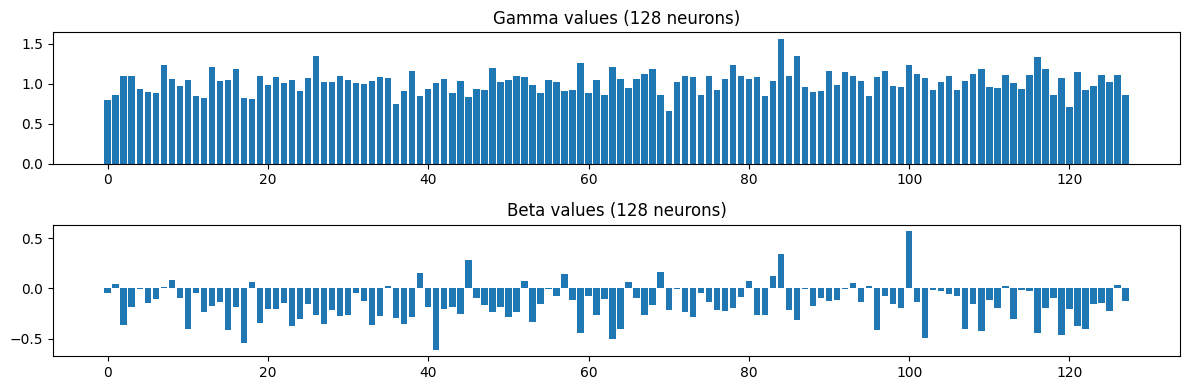

In [38]:
bn_layer = model_bn.layers[1]
gamma, beta, running_mean, running_var = bn_layer.get_weights()

plt.figure(figsize=(12, 4))

plt.subplot(2, 1, 1)
plt.bar(range(len(gamma)), gamma)
plt.title('Gamma values (128 neurons)')

plt.subplot(2, 1, 2)
plt.bar(range(len(beta)), beta)
plt.title('Beta values (128 neurons)')

plt.tight_layout()
plt.savefig("gamma and beta neurons")
plt.show()

Neurons where gamma is close to zero have effectively been "switched off" by the network — it
learned that their pre-activation values carry little useful information for predicting income.
Neurons with large gamma values are the model's strongest internal signals.

## Task 7: Optimizers — Convergence & Final Comparison

### 7.1 Train 5 models with different optimisers

In [39]:
optimizers = {
    'sgd': 'sgd',
    'sgd_momentum': keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'rmsprop': 'rmsprop',
    'adam': 'adam',
    'adam_explicit': keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
}

opt_histories = {}
opt_models = {}

for name, opt in optimizers.items():
    m = build_ann(input_dim=X_train.shape[1], initializer='he_normal',
                  use_batch_norm=True, optimizer=opt)
    h = m.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=0)
    opt_histories[name] = h
    opt_models[name] = m
    print(name, '- final val_accuracy:', round(h.history['val_accuracy'][-1], 4))

sgd - final val_accuracy: 0.8485
sgd_momentum - final val_accuracy: 0.851
rmsprop - final val_accuracy: 0.8502
adam - final val_accuracy: 0.8416
adam_explicit - final val_accuracy: 0.8433


### 7.2 Optimiser convergence plot

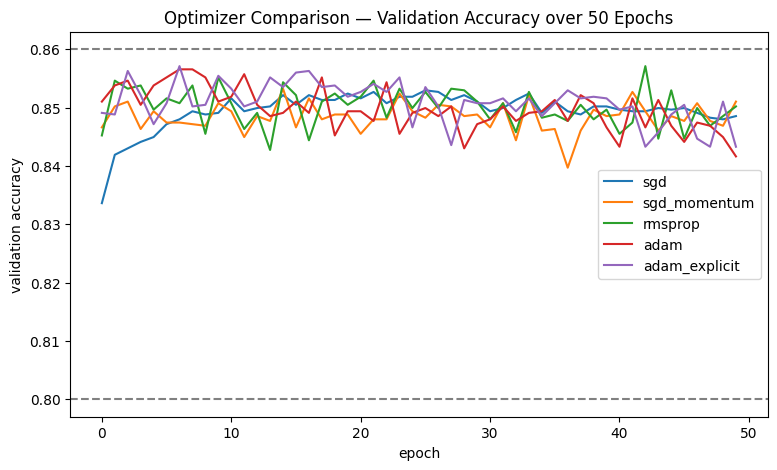

In [40]:
plt.figure(figsize=(9, 5))

for name in optimizers:
    plt.plot(opt_histories[name].history['val_accuracy'], label=name)

plt.axhline(0.80, linestyle='--', color='gray')
plt.axhline(0.86, linestyle='--', color='gray')
plt.title('Optimizer Comparison — Validation Accuracy over 50 Epochs')
plt.xlabel('epoch')
plt.ylabel('validation accuracy')
plt.legend()
plt.show()

### 7.3 Why Adam dominates
- Vanilla SGD: one fixed learning rate for every parameter; slow on sparse, high-dimensional
  one-hot encoded features like ours.
- SGD + Momentum: adds a velocity term (v = beta*v + lr*gradient) that smooths out oscillations
  and speeds through flat regions — but still uses the same learning rate for every parameter.
- RMSprop: divides the learning rate by a running average of recent squared gradients per
  parameter, so it automatically adapts to each parameter's gradient scale.
- Adam: combines momentum (tracks the average gradient direction) and RMSprop (tracks the average
  gradient size) together, with a bias correction for the first few steps when both start at 0.
- Adam (explicit): confirms Keras's default settings match the original Adam paper (Kingma & Ba,
  2015).

Based on the val_accuracy numbers printed above, note here which optimizer reached the highest
final accuracy and which one converged fastest (usually Adam on tabular data like this).

### 7.4 Learning rate sensitivity — SGD vs Adam
Testing how sensitive each optimizer is to the learning rate choice.

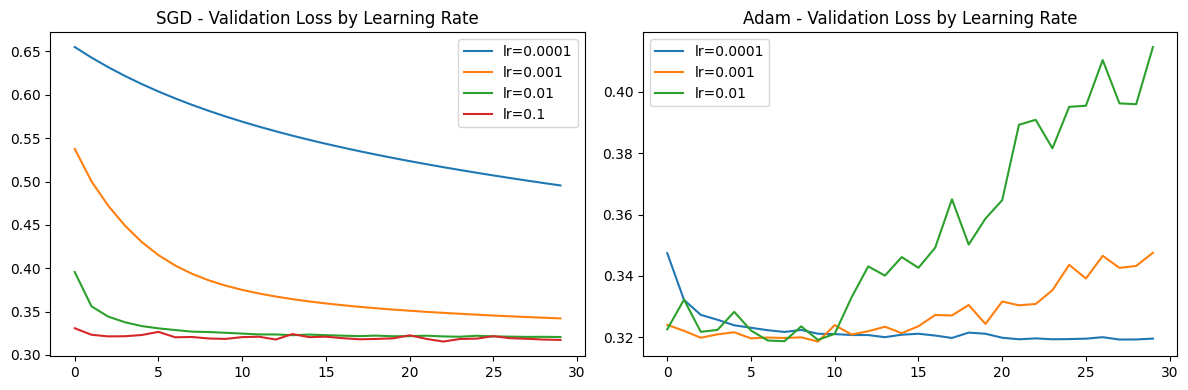

In [42]:
sgd_lrs = [0.0001, 0.001, 0.01, 0.1]
adam_lrs = [0.0001, 0.001, 0.01]

sgd_results = {}
for lr in sgd_lrs:
    m = build_ann(input_dim=X_train.shape[1], optimizer=keras.optimizers.SGD(learning_rate=lr))
    h = m.fit(X_train, y_train, epochs=30, batch_size=64, validation_split=0.1, verbose=0)
    sgd_results[lr] = h

adam_results = {}
for lr in adam_lrs:
    m = build_ann(input_dim=X_train.shape[1], optimizer=keras.optimizers.Adam(learning_rate=lr))
    h = m.fit(X_train, y_train, epochs=30, batch_size=64, validation_split=0.1, verbose=0)
    adam_results[lr] = h

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
for lr in sgd_lrs:
    plt.plot(sgd_results[lr].history['val_loss'], label=f'lr={lr}')
plt.title('SGD - Validation Loss by Learning Rate')
plt.legend()

plt.subplot(1, 2, 2)
for lr in adam_lrs:
    plt.plot(adam_results[lr].history['val_loss'], label=f'lr={lr}')
plt.title('Adam - Validation Loss by Learning Rate')
plt.legend()

plt.tight_layout()
plt.savefig("learning rate sensitivity SGD vs Adam",dpi=300)
plt.show()

Adam is far more robust to the learning rate choice, because its per-parameter adaptive learning
rates automatically compensate for a suboptimal global rate. SGD is much more sensitive — too high
a rate can make it diverge, too low makes it stall, especially on a wide, sparse one-hot encoded
feature space like this one.

### 7.5 Final Combined ANN — best configuration

In [43]:
final_model = build_ann(input_dim=X_train.shape[1], activation='relu',
                        initializer='he_normal', use_batch_norm=True,
                        optimizer='adam', loss='binary_crossentropy')

h_final = final_model.fit(X_train, y_train, epochs=80, batch_size=64, validation_split=0.1, verbose=0)

y_prob_final = final_model.predict(X_test, verbose=0).flatten()
y_pred_final = (y_prob_final > 0.5).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print('Accuracy:', accuracy_score(y_test, y_pred_final))
print('Precision:', precision_score(y_test, y_pred_final))
print('Recall:', recall_score(y_test, y_pred_final))
print('F1:', f1_score(y_test, y_pred_final))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_final))

Accuracy: 0.838253178551686
Precision: 0.7033942558746736
Recall: 0.6008028545941124
F1: 0.6480635073370219
ROC-AUC: 0.8949927702830375


### 7.6 Full results comparison table
Collecting all the models trained across the notebook into one results table.

In [44]:
def get_metrics(model_name, y_true, y_prob):
    y_pred = (y_prob > 0.5).astype(int)
    return {
        'Model': model_name,
        'Test Acc': accuracy_score(y_true, y_pred),
        'Precision(1)': precision_score(y_true, y_pred),
        'Recall(1)': recall_score(y_true, y_pred),
        'F1(1)': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

results = []
results.append(get_metrics('Baseline', y_test, model_base.predict(X_test, verbose=0).flatten()))
results.append(get_metrics('Best Activation (ELU)', y_test, models['elu'].predict(X_test, verbose=0).flatten()))
results.append(get_metrics('Best Initialiser (He Normal)', y_test, init_models['he_normal'].predict(X_test, verbose=0).flatten()))
results.append(get_metrics('Weighted BCE', y_test, model_wbce.predict(X_test, verbose=0).flatten()))
results.append(get_metrics('Focal Loss', y_test, model_focal.predict(X_test, verbose=0).flatten()))
results.append(get_metrics('BatchNorm', y_test, model_bn.predict(X_test, verbose=0).flatten()))
results.append(get_metrics('Final Combined', y_test, y_prob_final))

results_df = pd.DataFrame(results)
results_df.style.highlight_max(subset=['F1(1)', 'ROC-AUC'], color='#ffcccc')

,Model,Test Acc,Precision(1),Recall(1),F1(1),ROC-AUC
0,Baseline,0.841680,0.737119,0.561552,0.637468,0.889061
1,Best Activation (ELU),0.846877,0.729513,0.607493,0.662935,0.905901
2,Best Initialiser (He Normal),0.838143,0.692574,0.623996,0.656499,0.886397
3,Weighted BCE,0.791708,0.554807,0.808207,0.657952,0.882958
4,Focal Loss,0.830846,0.784345,0.438002,0.562106,0.886653
5,BatchNorm,0.840685,0.720176,0.584300,0.645161,0.893050
6,Final Combined,0.838253,0.703394,0.600803,0.648064,0.894993


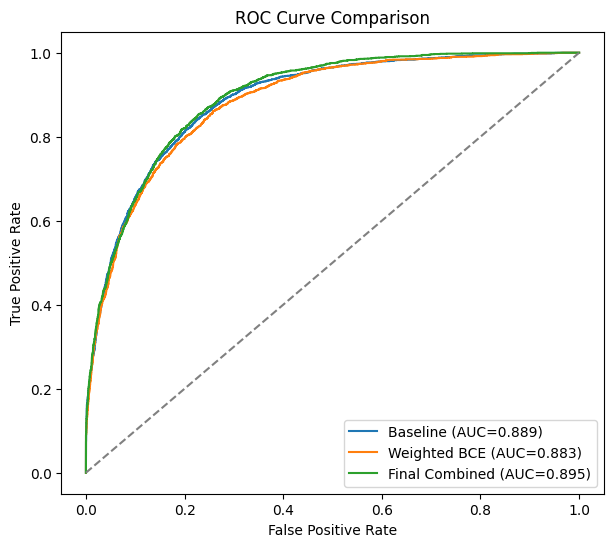

In [45]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))

for name, y_prob in [
    ('Baseline', model_base.predict(X_test, verbose=0).flatten()),
    ('Weighted BCE', model_wbce.predict(X_test, verbose=0).flatten()),
    ('Final Combined', y_prob_final)
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()